## 리텐션이 높은 코호트의 특징 분석
### 가설 설정

앞서 분석을 통해 리텐션이 높은 코호트는 단순히 평균 값이 높은 것이 아니라,  
여러 Range 구간에 걸쳐 **재구매 패턴이 지속적으로 나타나는 특징**을 보였다.

| 순위 | 코호트(첫 구매 기준) | R1 | R2 | R3 | R4 | 평균 리텐션 | 전체 평균 대비 |
|------|--------|-----|-----|-----|-----|------------|---------------|
| 1위 | 2024-05 | 10.6% | 10.9% | - | - | **10.75%** | **+36.1%** |
| 2위 | 2024-03 | 10.9% | 9.6% | 9.6% | - | **10.01%** | **+26.7%** |
| - | 전체 평균 | - | - | - | - | 7.90% | - |

이러한 차이는 고객의 구매 행동, 가격 민감도, 상품 선호도 등의 요인에서 기인할 가능성이 있다.  
따라서 본 분석에서는 리텐션 차이를 설명할 수 있는 주요 요인을 다음과 같은 가설을 통해 검증하고자 한다.

### **가설 2: 리텐션이 높은 코호트의 할인 제품 구매 비율이 전체 코호트와 상이할 것이다.**
→ 할인 및 프로모션은 재구매를 유도하는 주요 요인 중 하나로, 가격 혜택에 민감한 고객일수록 재구매 빈도가 높을 수 있다.

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()  # .env 파일 로드

# MySQL 연결
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)



# 2024년 전체 데이터의 할인에 따른 재구매 횟수
query_discount_2024 = """
WITH first_purchase AS (
	SELECT 
		CustomerID,
        MIN(OrderDate) AS first_purchase_date
	FROM orders_info
    GROUP BY CustomerID
),

customer_2024 AS (
	SELECT
		CustomerID,
        first_purchase_date
	FROM first_purchase
    WHERE YEAR(first_purchase_date) = 2024
),

all_orders AS (
	SELECT
		o.CustomerID,
        o.Discount,
        CASE WHEN o.Discount > 0 THEN 1 ELSE 0 END AS has_discount
    FROM orders_info o
    INNER JOIN customer_2024 c ON o.CustomerID = c.CustomerID
),

repurchase_orders AS (
    SELECT 
		o.CustomerID,
        o.Discount,
        CASE WHEN o.Discount > 0 THEN 1 ELSE 0 END AS has_discount
    FROM orders_info o
    INNER JOIN customer_2024 c ON o.CustomerID = c.CustomerID
    WHERE o.OrderDate > c.first_purchase_date
)

SELECT 
    COUNT(*) AS total_orders,
    SUM(has_discount) AS discount_orders,
    (SELECT COUNT(*) FROM repurchase_orders) AS total_repurchase_orders,
    (SELECT SUM(has_discount) FROM repurchase_orders) AS discount_repurchase_orders,
    ROUND(AVG(CASE WHEN Discount > 0 THEN Discount END), 4) AS avg_discount_rate
FROM all_orders
"""



# 리텐션이 높은 그룹 데이터의 할인에 따른 재구매 횟수
query_discount_2024_high_retention = """
WITH first_purchase AS (
	SELECT 
		CustomerID,
        MIN(OrderDate) AS first_purchase_date
	FROM orders_info
    GROUP BY CustomerID
),

customer_2024 AS (
    SELECT CustomerID, first_purchase_date
    FROM first_purchase
    WHERE YEAR(first_purchase_date) = 2024
      AND (MONTH(first_purchase_date) = 3 OR MONTH(first_purchase_date) = 5) 
),

all_orders AS (
	SELECT
		o.CustomerID,
        o.Discount,
        CASE WHEN o.Discount > 0 THEN 1 ELSE 0 END AS has_discount
    FROM orders_info o
    INNER JOIN customer_2024 c ON o.CustomerID = c.CustomerID
),

repurchase_orders AS (
    SELECT 
		o.CustomerID,
        o.Discount,
        CASE WHEN o.Discount > 0 THEN 1 ELSE 0 END AS has_discount
    FROM orders_info o
    INNER JOIN customer_2024 c ON o.CustomerID = c.CustomerID
    WHERE o.OrderDate > c.first_purchase_date
)

SELECT 
    COUNT(*) AS total_orders,
    SUM(has_discount) AS discount_orders,
    (SELECT COUNT(*) FROM repurchase_orders) AS total_repurchase_orders,
    (SELECT SUM(has_discount) FROM repurchase_orders) AS discount_repurchase_orders,
    ROUND(AVG(CASE WHEN Discount > 0 THEN Discount END), 4) AS avg_discount_rate
FROM all_orders
"""

df_discount_2024 = pd.read_sql(query_discount_2024, engine)
df_discount_2024_high_retention = pd.read_sql(query_discount_2024_high_retention, engine)

In [2]:
# 백분율로 변환
df_discount_2024['avg_discount_rate'] = df_discount_2024['avg_discount_rate'] * 100
df_discount_2024_high_retention['avg_discount_rate'] = df_discount_2024_high_retention['avg_discount_rate'] * 100

In [3]:
df_discount_2024

,total_orders,discount_orders,total_repurchase_orders,discount_repurchase_orders,avg_discount_rate
0,3944,2348.0,681,392.0,12.36


In [17]:
df_discount_2024_high_retention

,total_orders,discount_orders,total_repurchase_orders,discount_repurchase_orders,avg_discount_rate
0,790,465.0,193,110.0,12.97


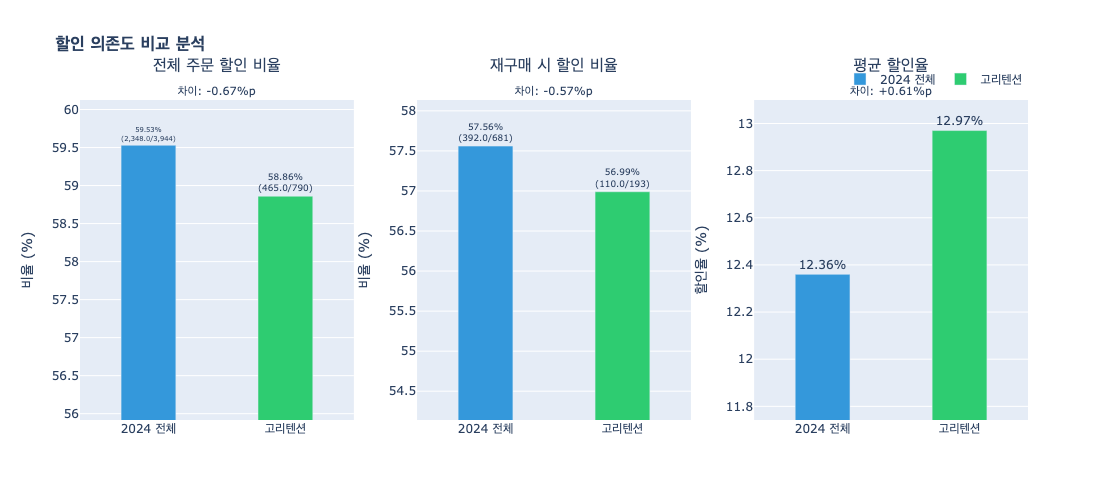

In [30]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 데이터 계산
all_ratio_2024 = round(discount_2024 / total_2024 * 100, 2)
all_ratio_high = round(discount_high / total_high * 100, 2)
diff_all = all_ratio_high - all_ratio_2024

repurchase_ratio_2024 = round(repurchase_discount_2024 / repurchase_total_2024 * 100, 2)
repurchase_ratio_high = round(repurchase_discount_high / repurchase_total_high * 100, 2)
diff_repurchase = repurchase_ratio_high - repurchase_ratio_2024

avg_rate_2024 = df_discount_2024['avg_discount_rate'].iloc[0]
avg_rate_high = df_discount_2024_high_retention['avg_discount_rate'].iloc[0]
diff_avg = avg_rate_high - avg_rate_2024

# 서브플롯 생성
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        f'전체 주문 할인 비율<br><sub>차이: {diff_all:+.2f}%p</sub>',
        f'재구매 시 할인 비율<br><sub>차이: {diff_repurchase:+.2f}%p</sub>',
        f'평균 할인율<br><sub>차이: {diff_avg:+.2f}%p</sub>'
    ),
    specs=[[{"type": "bar"}, {"type": "bar"}, {"type": "bar"}]]
)

# 1. 전체 주문 할인 비율
fig.add_trace(
    go.Bar(
        x=['2024 전체'],
        y=[all_ratio_2024],
        text=[f"{all_ratio_2024}%<br>({discount_2024:,}/{total_2024:,})"],
        textposition='outside',
        marker_color='#3498db',
        name='2024 전체',
        showlegend=True,
        width=0.4
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=['고리텐션'],
        y=[all_ratio_high],
        text=[f"{all_ratio_high}%<br>({discount_high:,}/{total_high:,})"],
        textposition='outside',
        marker_color='#2ecc71',
        name='고리텐션',
        showlegend=True,
        width=0.4
    ),
    row=1, col=1
)

# 2. 재구매 시 할인 비율
fig.add_trace(
    go.Bar(
        x=['2024 전체'],
        y=[repurchase_ratio_2024],
        text=[f"{repurchase_ratio_2024}%<br>({repurchase_discount_2024:,}/{repurchase_total_2024:,})"],
        textposition='outside',
        marker_color='#3498db',
        showlegend=False,
        width=0.4
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=['고리텐션'],
        y=[repurchase_ratio_high],
        text=[f"{repurchase_ratio_high}%<br>({repurchase_discount_high:,}/{repurchase_total_high:,})"],
        textposition='outside',
        marker_color='#2ecc71',
        showlegend=False,
        width=0.4
    ),
    row=1, col=2
)

# 3. 평균 할인율
fig.add_trace(
    go.Bar(
        x=['2024 전체'],
        y=[avg_rate_2024],
        text=[f"{avg_rate_2024:.2f}%"],
        textposition='outside',
        marker_color='#3498db',
        showlegend=False,
        width=0.4
    ),
    row=1, col=3
)

fig.add_trace(
    go.Bar(
        x=['고리텐션'],
        y=[avg_rate_high],
        text=[f"{avg_rate_high:.2f}%"],
        textposition='outside',
        marker_color='#2ecc71',
        showlegend=False,
        width=0.4
    ),
    row=1, col=3
)

# y축 범위 더 좁게 조정 (차이 강조)
y_min_1 = min(all_ratio_2024, all_ratio_high) * 0.95  # 0.9 → 0.95
y_max_1 = max(all_ratio_2024, all_ratio_high) * 1.01  # 1.1 → 1.05

y_min_2 = min(repurchase_ratio_2024, repurchase_ratio_high) * 0.95
y_max_2 = max(repurchase_ratio_2024, repurchase_ratio_high) * 1.01

y_min_3 = min(avg_rate_2024, avg_rate_high) * 0.95
y_max_3 = max(avg_rate_2024, avg_rate_high) * 1.01

fig.update_yaxes(title_text="비율 (%)", range=[y_min_1, y_max_1], row=1, col=1)
fig.update_yaxes(title_text="비율 (%)", range=[y_min_2, y_max_2], row=1, col=2)
fig.update_yaxes(title_text="할인율 (%)", range=[y_min_3, y_max_3], row=1, col=3)

fig.update_layout(
    title_text='<b>할인 의존도 비교 분석</b>',
    height=500,
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()

## 가설 2: 할인 의존도 비교 분석

### 가설
**리텐션이 높은 코호트는 할인 없이도 재구매할 가능성이 높을 것이다.**

할인은 단기적 구매 유도 수단이지만, 진정한 충성 고객은 제품 만족도를 기반으로 정가에도 재구매할 가능성이 있다. 리텐션이 높은 코호트의 할인 의존도를 분석하여 효율적인 마케팅 전략을 수립한다.

---

### 분석 결과

#### 할인 패턴 비교

| 구분 | 2024 전체 | 고리텐션 코호트 | 차이 |
|------|-----------|----------------|------|
| 전체 주문 할인 비율 | 59.53% (2,348/3,944) | 58.86% (465/790) | -0.67%p |
| 재구매 시 할인 비율 | 57.56% (392/681) | 56.99% (110/193) | -0.57%p |
| 평균 할인율 | 12.36% | 12.97% | +0.61%p |

리텐션이 높은 코호트와 전체 코호트의 할인 의존도는 **거의 동일**함 (최대 차이 0.67%p). 두 그룹 모두 약 59%가 할인 주문을 하며, 재구매 시에도 약 57%가 할인을 받음.

---

### 가설 검증 결과

**가설 기각**

리텐션이 높은 코호트와 전체 코호트의 할인 의존도는 **유의미한 차이가 없음** (최대 차이 0.67%p). 충성 고객도 일반 고객만큼 할인에 의존하며, 할인은 리텐션에 **직접적인 영향을 주는 주요 요인이 아님**으로 판단됨.

---

### 핵심 발견

**1. 할인 의존도 동일**
- 전체 주문: 59.53% vs 58.86% (차이 0.67%p)
- 재구매 시: 57.56% vs 56.99% (차이 0.57%p)
- **의미:** 충성 고객도 일반 고객만큼 할인에 의존

**2. 전반적으로 높은 할인 선호**
- 두 그룹 모두 약 60%가 할인 주문
- 할인은 전반적인 구매 동기이지만, 리텐션 차별화 요인은 아님

---

## 💡 제언

### 할인 전략 현상 유지 및 효율화

할인 의존도가 리텐션과 무관하므로 현재 할인 정책을 유지하되, **효율성 개선과 할인 외 가치 제공**에 집중한다.

---

**1. 로열티 프로그램으로 재구매 선순환 구축**

멤버십 고객에게 구매 시 다양한 혜택을 제공하여 할인 의존도를 낮추고 지속적인 재구매를 유도한다.

- 멤버십 자동 결제 서비스 (예: 네이버 플러스 멤버십, G마켓 스마일 클럽)
- 멤버십 회원 전용 비정기 깜짝 이벤트 쿠폰
- 전 품목 무료배송 혜택
- 결제 시 추가 포인트 적립 (일반 고객 대비 2배)
- 등급별 차등 혜택 (실버 → 골드 → VIP)

**2. 고객 세그먼트별 차등 할인**

모든 고객에게 동일한 할인을 제공하기보다, 고객 상태에 따라 전략적으로 할인을 차등 적용한다.

- **신규 고객:** 첫 구매 유도 높은 할인 (15~20%)
- **충성 고객:** 멤버십 혜택 중심, 낮은 할인율 (5~10%)
- **이탈 위험 고객:** 재활성화 할인 (20~30%)

**3. 개인화된 할인 및 추천**

구매 패턴 기반 개인화 전략으로 할인 효율성을 높이고 재구매를 유도한다.

- 구매 주기 기반 자동 쿠폰 발송 (평균 구매 주기 - 5일 시점)
- 선호 카테고리 맞춤 할인 (Home & Kitchen 고객 → 주방용품 쿠폰)
- AI 기반 추천 시스템 (이전 구매 기반 상품 추천)
- 생일, 가입 기념일 특별 할인

**4. 뉴스레터 및 콘텐츠 마케팅**

정보 제공 및 스토리텔링을 활용한 뉴스레터로 브랜드 호감도를 높여 충성도를 확보한다.

- 카테고리별 전문 콘텐츠 (예: Books 고객 → 신간 서평, 작가 인터뷰)
- Home & Kitchen 고객 → 레시피, 주방 팁
- 월 1회 정기 뉴스레터 + 특별 쿠폰 동봉

**5. 배송 및 고객 서비스 강화**

할인 외 가치 제공을 통해 제품 만족도와 브랜드 충성도를 높인다.

- 충성 고객 대상 익일 배송 서비스
- 프리미엄 포장 + 감사 메시지 카드
- VIP 고객 전담 상담 채널 (우선 응대)
- 반품/교환 간소화 (무료 반품, 즉시 환불)